# AEL/PEM electrolysis + HB ammonia NPV simulation

Run the Monte Carlo ammonia NPV model for AEL/PEM electrolysis + HB at 1,000,000 tNH3/year. The notebook shows NPV, LNM, and LCOA distributions, NPV sign counts, and mean annual cost components.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution

pd.options.display.float_format = "{:,.3f}".format

In [2]:
TECHNOLOGY = "ael_pem_electrolysis_hb"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

simulation = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()

,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tnh3,lifetime_years,capex_eur_per_tnh3,fixed_opex_eur_per_tnh3,variable_opex_eur_per_tnh3,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tnh3,present_value_total_cost_eur,lcoa_eur_per_tnh3,levelized_net_margin_eur_per_tnh3
0,0,ael_pem_electrolysis_hb,absolute,not_applicable,"1,000,000.000",25,"2,587.533",44.272,4.389,none,...,"1,079,591,681.311",0.000,0.000,"1,128,253,315.896","-238,253,315.896","-5,130,833,642.746","10,674,776.189","14,631,384,450.590","1,370.650",-480.650
1,1,ael_pem_electrolysis_hb,absolute,not_applicable,"1,000,000.000",25,"1,784.463",40.389,3.226,none,...,"1,195,358,192.871",0.000,0.000,"1,238,973,809.176","-348,973,809.176","-5,509,679,964.436","10,674,776.189","15,010,230,772.280","1,406.140",-516.140
2,2,ael_pem_electrolysis_hb,absolute,not_applicable,"1,000,000.000",25,"1,628.247",34.961,3.376,none,...,"884,126,533.756",0.000,0.000,"922,463,765.631","-32,463,765.631","-1,974,790,302.574","10,674,776.189","11,475,341,110.418","1,074.996",-184.996
3,3,ael_pem_electrolysis_hb,absolute,not_applicable,"1,000,000.000",25,"2,392.459",34.591,3.739,none,...,"1,183,993,622.302",0.000,0.000,"1,222,324,391.444","-332,324,391.444","-5,939,947,509.612","10,674,776.189","15,440,498,317.456","1,446.447",-556.447
4,4,ael_pem_electrolysis_hb,absolute,not_applicable,"1,000,000.000",25,"2,227.700",40.746,3.462,none,...,"1,263,450,282.120",0.000,0.000,"1,307,658,555.753","-417,658,555.753","-6,686,111,741.420","10,674,776.189","16,186,662,549.264","1,516.347",-626.347


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoa_eur_per_tnh3 = results["lcoa_eur_per_tnh3"]
levelized_net_margin_eur_per_tnh3 = results["levelized_net_margin_eur_per_tnh3"]

summary = pd.concat([
    npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename("NPV million EUR"),
    levelized_net_margin_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LNM EUR/tNH3"),
    lcoa_eur_per_tnh3.describe(percentiles=[0.05, 0.5, 0.95]).rename("LCOA EUR/tNH3"),
], axis=1)
npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame([
    {"NPV category": "Non-negative (NPV >= 0)", "Count": npv_signs["non_negative_count"], "Share": npv_signs["non_negative_share"]},
    {"NPV category": "Negative (NPV < 0)", "Count": npv_signs["negative_count"], "Share": 1 - npv_signs["non_negative_share"]},
])
display(summary, npv_sign_summary)

,NPV million EUR,LNM EUR/tNH3,LCOA EUR/tNH3
count,"100,000.000","100,000.000","100,000.000"
mean,"-4,692.220",-439.561,"1,329.561"
std,"2,523.109",236.362,236.362
min,"-11,579.277","-1,084.733",726.894
5%,"-8,823.395",-826.565,945.436
50%,"-4,684.471",-438.836,"1,328.836"
95%,-591.770,-55.436,"1,716.565"
max,"1,741.116",163.106,"1,974.733"


,NPV category,Count,Share
0,Non-negative (NPV >= 0),1959,0.020
1,Negative (NPV < 0),98041,0.980


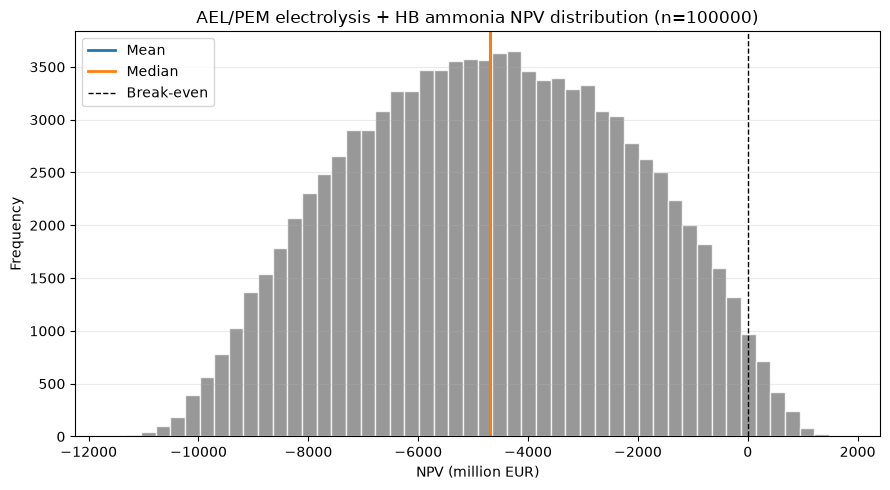

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"AEL/PEM electrolysis + HB ammonia NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()

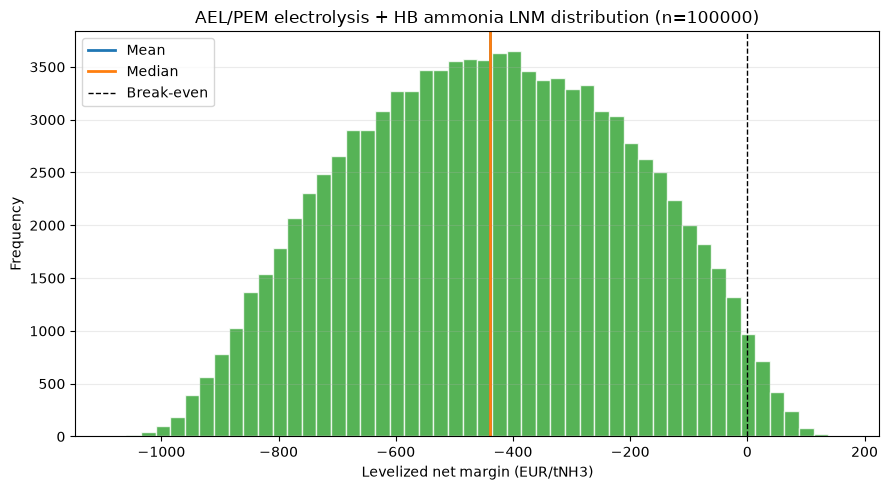

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tnh3,
    title=f"AEL/PEM electrolysis + HB ammonia LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tNH3)",
    color="tab:green",
    show_break_even=True,
)
plt.show()

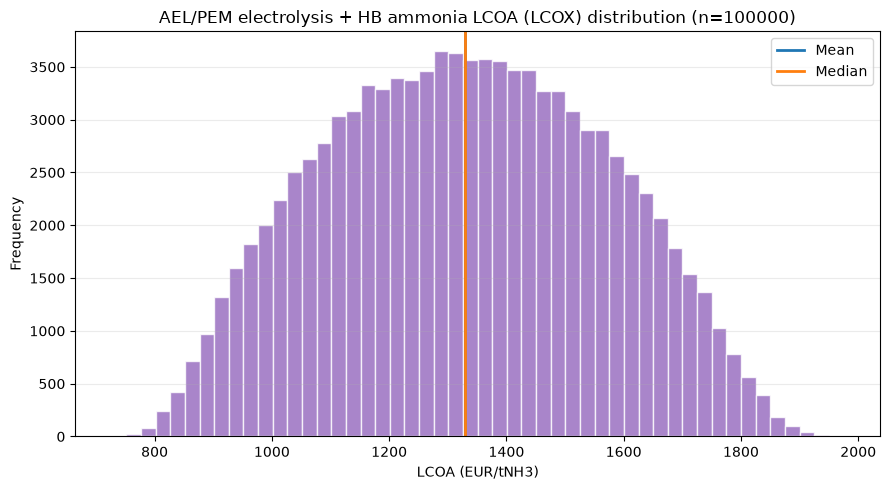

In [6]:
plot_financial_metric_distribution(
    lcoa_eur_per_tnh3,
    title=f"AEL/PEM electrolysis + HB ammonia LCOA (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOA (EUR/tNH3)",
    color="tab:purple",
)
plt.show()

In [7]:
annual_columns = [
    "annual_revenue_eur",
    "annual_fixed_opex_eur",
    "annual_variable_opex_eur",
    "annual_natural_gas_cost_eur",
    "annual_coal_cost_eur",
    "annual_biomass_cost_eur",
    "annual_fuel_cost_eur",
    "annual_electricity_cost_eur",
    "annual_transport_and_storage_cost_eur",
    "annual_emissions_cost_eur",
    "annual_net_cash_flow_eur",
]
(results[annual_columns] / 1_000_000).mean().rename("Mean annual value, million EUR")

annual_revenue_eur                        890.000
annual_fixed_opex_eur                      39.775
annual_variable_opex_eur                    3.703
annual_natural_gas_cost_eur                 0.000
annual_coal_cost_eur                        0.000
annual_biomass_cost_eur                     0.000
annual_fuel_cost_eur                        0.000
annual_electricity_cost_eur             1,096.056
annual_transport_and_storage_cost_eur       0.000
annual_emissions_cost_eur                   0.000
annual_net_cash_flow_eur                 -249.534
Name: Mean annual value, million EUR, dtype: float64